In [3]:
# Install plotting libraries into the current notebook environment
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # type: ignore
import seaborn as sns  # type: ignore

sns.set(style="whitegrid")

In [4]:
df = pd.read_parquet("ratings.parquet")
df.head()

,noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification
0,1357294499052085249,1357269755112148993,FE4BA8F630E66459C9F2EEBDDF69C4B22D222AD55E9013...,FB8A5B50F04AAB7CCEA99B4094EAA1AD8E49E3503EF18E...,2021-02-04 10:08:21.128,2021-02-04 11:46:40.544,2026-02-01 14:36:13.314,NOT_HELPFUL,False
1,1357297935407603713,1357269755112148993,FE4BA8F630E66459C9F2EEBDDF69C4B22D222AD55E9013...,B9BEE8138A8A67538391BC79C1E9DFF614FCEE2DD089CB...,2021-02-04 10:08:21.128,2021-02-04 12:00:19.835,2026-02-01 14:36:04.345,NOT_HELPFUL,False
2,1358604958673719296,1358464064322691078,456D1C422BA1A09690B986C8A1DBE7627D10462AF965A0...,FAB1117EE31D648BA7C11062F626AF7B6908D551B4C9C8...,2021-02-07 17:14:06.633,2021-02-08 02:33:58.465,2026-02-09 08:56:34.712,NOT_HELPFUL,False
3,1358604958673719296,1358464064322691078,4B3821FC937ACD882F8BD4045DD281556154AC41E45387...,FAB1117EE31D648BA7C11062F626AF7B6908D551B4C9C8...,2021-02-07 17:14:06.633,2021-02-08 02:33:58.465,2026-02-09 00:51:34.502,NOT_HELPFUL,False
4,1358844963216326659,1358464064322691078,4B3821FC937ACD882F8BD4045DD281556154AC41E45387...,605A405C64CC57A943D086CC80E5AC35A57605B4CEE3D8...,2021-02-07 17:14:06.633,2021-02-08 18:27:40.007,2026-02-09 00:51:18.076,NOT_HELPFUL,False


### Timestamp parsing + sorting for sequential logic
I converted the timestamp columns (`ratingCreatedAt`, `noteCreatedAt`, `postCreatedAt`) into true datetime objects so I could compute accurate time gaps. I then sorted the DataFrame by `raterParticipantId` and `ratingCreatedAt` to put each user’s ratings in chronological order. This ordering is essential for identifying rating sessions, because session detection depends on comparing each rating to the user’s previous and next ratings in time.

In [5]:
# Time Transform
df["ratingCreatedAt"] = pd.to_datetime(df["ratingCreatedAt"])
df["noteCreatedAt"] = pd.to_datetime(df["noteCreatedAt"])
df["postCreatedAt"] = pd.to_datetime(df["postCreatedAt"])

df = df.sort_values(["raterParticipantId", "ratingCreatedAt"]).reset_index(drop=True)

### Rating session attribution (gap within 5 minutes)
To infer whether a rating occurred as part of a “rating session,” I computed the time difference between each rating and the previous rating by the same user (`gap_prev`), as well as the difference to the next rating (`gap_next`). I labeled a rating as `is_rating_session = True` if it was within 5 minutes of either its previous or next rating. This approach marks all ratings that belong to a continuous burst of activity, rather than only marking the first rating in a burst, which better matches the idea of a user rating multiple notes in one continuous block.

In [6]:
# Was the rating apart of a "rating session,"
gap_prev = df.groupby("raterParticipantId")["ratingCreatedAt"].diff()
gap_next = df.groupby("raterParticipantId")["ratingCreatedAt"].diff(-1).abs()

df["is_rating_session"] = (
    (gap_prev <= pd.Timedelta(minutes=5)) |
    (gap_next <= pd.Timedelta(minutes=5))
)

df["is_rating_session"] = df["is_rating_session"].fillna(False)

df

,noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,is_rating_session
0,2016534713742061788,2016246745739546987,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,FD7979DE7F187DC14A4FDF8F5572424D060AA56E50AB30...,2026-01-27 20:27:38.894,2026-01-28 15:31:55.816,2026-01-28 20:47:22.321,HELPFUL,False,False
1,2017641230612451495,2017578816177111423,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2CE75633DDBFF074EE77E7DC582D7B557DC4D737E5FD81...,2026-01-31 12:40:49.235,2026-01-31 16:48:49.996,2026-01-31 17:21:23.365,HELPFUL,False,False
2,2018404224149717157,2018387895459983768,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,54F0002E8A4890D64140C45F5D108C9D76FDA829A157A0...,2026-02-02 18:15:48.768,2026-02-02 19:20:41.831,2026-02-02 22:44:01.605,HELPFUL,False,False
3,2012648760455671942,2012586343008755726,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,B5A7C39C8965D9D8AF5CC38B994AAC58DE5374B7660F88...,2026-01-17 18:02:30.876,2026-01-17 22:10:32.357,2026-01-18 15:41:27.835,NOT_HELPFUL,False,True
4,2012693431319990371,2012586343008755726,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,D174DF64F45A03029780F273B4335CE8D87C68A9DAF7EB...,2026-01-17 18:02:30.876,2026-01-18 01:08:02.720,2026-01-18 15:44:04.360,HELPFUL,False,True
...,...,...,...,...,...,...,...,...,...,...
6499630,2020752418963669036,2020604630657302841,FFFFBBAB3C66ABB4DBC2A3B486C3C673345C89B5858465...,BA48B1306E38D71468370309229E1842BDB92CF4F7917A...,2026-02-08 21:04:19.624,2026-02-09 06:51:35.102,2026-02-09 08:02:06.384,NOT_HELPFUL,False,False
6499631,2021916824426701208,2021784932818067904,FFFFBBAB3C66ABB4DBC2A3B486C3C673345C89B5858465...,E6ABEA01CD00795F7897A1245141FF57C05A9C136F6AE6...,2026-02-12 03:14:25.588,2026-02-12 11:58:30.999,2026-02-12 15:50:43.969,HELPFUL,False,False
6499632,2019488960465031197,2019467286298472468,FFFFC46B8555A97065DB39F7D600C8BB643F7F3EBD810E...,8D8A300EC055D96FC685C886688785A6A5F8BD49663F0F...,2026-02-05 17:44:55.598,2026-02-05 19:11:03.122,2026-02-06 08:34:11.398,HELPFUL,False,False
6499633,2013458308682690872,2013361050352050642,FFFFFE8909485374E33854B934713713CAC93CDB50C9D0...,4F0866C36C86735E6D9A3DF709775EEDCFA2180684FD72...,2026-01-19 21:20:55.500,2026-01-20 03:47:23.693,2026-01-20 22:31:31.668,HELPFUL,False,False


### Interest-based attribution (multiple notes on the same post)
To capture whether a rating was likely driven by interest in a specific post, I measured whether the same user rated multiple different notes attached to the same `ratedOnTweetId`. I grouped by (`raterParticipantId`, `ratedOnTweetId`) and computed the number of unique `noteId` values the user rated on that tweet. I then set `is_interest_based = True` when that count was greater than 1, meaning the user evaluated more than one Community Note on the same post.

In [7]:
# Was the rating based on interest in the post
df["notes_on_same_post_by_rater"] = (
    df.groupby(["raterParticipantId", "ratedOnTweetId"])["noteId"]
      .transform("nunique")
)

df["is_interest_based"] = df["notes_on_same_post_by_rater"] > 1

### Notification attribution (direct column mapping)
For the notification pathway, the dataset already includes a boolean signal (`fromNotification`) indicating whether the rating originated from a notification surface. I therefore set `is_notification` directly equal to this column. 

In [8]:
# Was the rating from a notification
df["is_notification"] = df["fromNotification"]
df

,noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,is_rating_session,notes_on_same_post_by_rater,is_interest_based,is_notification
0,2016534713742061788,2016246745739546987,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,FD7979DE7F187DC14A4FDF8F5572424D060AA56E50AB30...,2026-01-27 20:27:38.894,2026-01-28 15:31:55.816,2026-01-28 20:47:22.321,HELPFUL,False,False,1,False,False
1,2017641230612451495,2017578816177111423,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2CE75633DDBFF074EE77E7DC582D7B557DC4D737E5FD81...,2026-01-31 12:40:49.235,2026-01-31 16:48:49.996,2026-01-31 17:21:23.365,HELPFUL,False,False,1,False,False
2,2018404224149717157,2018387895459983768,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,54F0002E8A4890D64140C45F5D108C9D76FDA829A157A0...,2026-02-02 18:15:48.768,2026-02-02 19:20:41.831,2026-02-02 22:44:01.605,HELPFUL,False,False,1,False,False
3,2012648760455671942,2012586343008755726,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,B5A7C39C8965D9D8AF5CC38B994AAC58DE5374B7660F88...,2026-01-17 18:02:30.876,2026-01-17 22:10:32.357,2026-01-18 15:41:27.835,NOT_HELPFUL,False,True,2,True,False
4,2012693431319990371,2012586343008755726,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,D174DF64F45A03029780F273B4335CE8D87C68A9DAF7EB...,2026-01-17 18:02:30.876,2026-01-18 01:08:02.720,2026-01-18 15:44:04.360,HELPFUL,False,True,2,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499630,2020752418963669036,2020604630657302841,FFFFBBAB3C66ABB4DBC2A3B486C3C673345C89B5858465...,BA48B1306E38D71468370309229E1842BDB92CF4F7917A...,2026-02-08 21:04:19.624,2026-02-09 06:51:35.102,2026-02-09 08:02:06.384,NOT_HELPFUL,False,False,1,False,False
6499631,2021916824426701208,2021784932818067904,FFFFBBAB3C66ABB4DBC2A3B486C3C673345C89B5858465...,E6ABEA01CD00795F7897A1245141FF57C05A9C136F6AE6...,2026-02-12 03:14:25.588,2026-02-12 11:58:30.999,2026-02-12 15:50:43.969,HELPFUL,False,False,1,False,False
6499632,2019488960465031197,2019467286298472468,FFFFC46B8555A97065DB39F7D600C8BB643F7F3EBD810E...,8D8A300EC055D96FC685C886688785A6A5F8BD49663F0F...,2026-02-05 17:44:55.598,2026-02-05 19:11:03.122,2026-02-06 08:34:11.398,HELPFUL,False,False,1,False,False
6499633,2013458308682690872,2013361050352050642,FFFFFE8909485374E33854B934713713CAC93CDB50C9D0...,4F0866C36C86735E6D9A3DF709775EEDCFA2180684FD72...,2026-01-19 21:20:55.500,2026-01-20 03:47:23.693,2026-01-20 22:31:31.668,HELPFUL,False,False,1,False,False


### Rater swarm attribution (majority of note’s ratings concentrated in 1 hour)
To identify “rater swarms,” I switched perspective from user-level behavior to note-level behavior. I grouped ratings by `noteId` and examined the distribution of `ratingCreatedAt` times for each note. Using a sliding time window, I computed the maximum number of ratings that occurred within any 1-hour window for that note, then divided by the total ratings for the note to get a “peak share.” I labeled a note as a swarm if at least 50% of its ratings occurred in a single 1-hour window, and then mapped that note-level swarm flag back onto each rating as `is_rater_swarm`.

In [9]:
# Was the rating apart of a "rater swarm"

df = df.sort_values(["noteId", "ratingCreatedAt"]).reset_index(drop=True)

swarm_flag = {}
swarm_share = {}

for note_id, g in df.groupby("noteId"):
    times = g["ratingCreatedAt"].values
    n = len(times)

    if n < 5: 
        swarm_flag[note_id] = False
        swarm_share[note_id] = 0
        continue

    i = 0
    best = 1

    for j in range(n):
        while times[j] - times[i] > pd.Timedelta(hours=1):
            i += 1
        best = max(best, j - i + 1)

    share = best / n
    swarm_share[note_id] = share
    swarm_flag[note_id] = share >= 0.5

df["swarm_peak_share_1h"] = df["noteId"].map(swarm_share)
df["is_rater_swarm"] = df["noteId"].map(swarm_flag)

### Summary statistics
Lastly, I computed the mean of each boolean pathway column (`is_rating_session`, `is_interest_based`, `is_notification`, `is_rater_swarm`). Because these columns are True/False, the mean directly corresponds to the proportion of ratings attributed to each pathway. 

In [10]:
df[[
"is_rating_session",
"is_interest_based",
"is_notification",
"is_rater_swarm"
]].mean()

is_rating_session    0.590433
is_interest_based    0.509207
is_notification      0.019807
is_rater_swarm       0.033096
dtype: float64

### Results
The results show that approximately 59.0% of ratings occurred within a rating session, defined as multiple ratings by the same user within a five-minute window. This suggests that a majority of rating activity happens in batches, with many users evaluating several notes consecutively rather than rating only a single note in isolation.

About 50.9% of ratings were interest-based, meaning that the same user rated multiple notes associated with the same post. This indicates that a substantial portion of rating behavior may stem from engagement with a specific tweet, where users explore and evaluate multiple notes attached to it.

Only 2.0% of ratings originated from notifications. This suggests that notifications are not a major driver of rating activity, and most ratings appear to be user-initiated rather than prompted by system alerts.

3.3% of ratings were identified as part of a rater swarm, where a majority of ratings for a given note occurred within a short time window. This indicates that concentrated bursts of collective rating activity are relatively uncommon, and most notes receive ratings in a more distributed manner over time.

### 1a. Proportion of ratings attributed to each pathway
I wanted to summarize **how often each pathway shows up overall** in the data, using the boolean columns I already created (`is_rating_session`, `is_interest_based`, `is_notification`, `is_rater_swarm`).

Because these columns are `True`/`False`, their mean is exactly the proportion of ratings that fall into each pathway. I also computed raw counts next to the proportions so I can see not only which pathways are more common, but also whether any of them look suspiciously rare or overwhelmingly dominant. This helps check if one pathway is doing all the work or if attributions are more balanced.

In [11]:
# Overall pathway proportions (counts and shares)
pathway_cols = [
    "is_rating_session",
    "is_interest_based",
    "is_notification",
    "is_rater_swarm",
]

pathway_summary = pd.DataFrame({
    "count": df[pathway_cols].sum(),
    "proportion": df[pathway_cols].mean(),
}).sort_values("proportion", ascending=False)

pathway_summary

,count,proportion
is_rating_session,3837599,0.590433
is_interest_based,3309659,0.509207
is_rater_swarm,215110,0.033096
is_notification,128736,0.019807


### 1b. Visual check: are any pathways dominating all ratings?
To get a more intuitive feel for these proportions, I also plotted them as a bar chart. This makes it easier to visually compare the relative importance of each pathway and quickly spot anything that looks weird.
The y-axis here is just the share of all ratings that get tagged with each pathway, matching the table above. Because pathways are not mutually exclusive, the bars do not need to sum to 1; a single rating can contribute to multiple bars.

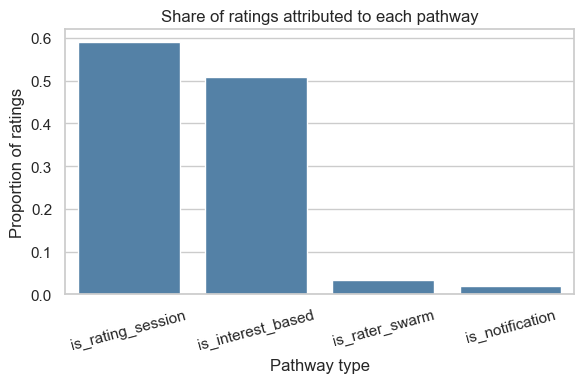

In [12]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=pathway_summary.index,
    y=pathway_summary["proportion"].values,
    color="steelblue",
)
ax.set_ylabel("Proportion of ratings")
ax.set_xlabel("Pathway type")
ax.set_title("Share of ratings attributed to each pathway")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 1c. Checking for conflicting or suspicious pathway combinations
The next thing I checked was **whether my attributions contradict each other in obvious ways**. A rating can legitimately come from multiple pathways, but some patterns should be rare if the logic is sensible.

To approximate "end of session" ratings, I recomputed the time gaps between a user's ratings and flagged ratings where:
- they are marked as part of a rating session, but
- they are followed by a long gap (more than 5 minutes) to the next rating.

I then counted how often these "end-of-session" ratings also come from notifications or swarms, and how often swarm ratings overlap with notifications or rating sessions in general. If these overlaps were extremely common, that would suggest my rules are too generous or overlapping in ways that don't make sense.

In [13]:
# Recompute gaps to approximate "end of session" ratings
rating_times = df.groupby("raterParticipantId")["ratingCreatedAt"]

gap_prev = rating_times.diff()
# Positive gap to next rating: time until the next rating by the same user
gap_next = rating_times.diff(-1).abs()

session_threshold = pd.Timedelta(minutes=5)

# Approximate end-of-session: part of a session, and the next rating is far away
is_session_end = (
    df["is_rating_session"] &
    (gap_next.isna() | (gap_next > session_threshold))
)

# 1) End-of-session ratings that also come from notifications or swarms
end_conflict_mask = is_session_end & (df["is_notification"] | df["is_rater_swarm"])

# 2) Swarm ratings that are also from notifications or rating sessions
swarm_conflict_mask = df["is_rater_swarm"] & (df["is_notification"] | df["is_rating_session"])

conflict_summary = pd.DataFrame({
    "total_ratings": [len(df)],
    "end_session_conflict_count": [end_conflict_mask.sum()],
    "end_session_conflict_share": [end_conflict_mask.mean()],
    "swarm_conflict_count": [swarm_conflict_mask.sum()],
    "swarm_conflict_share": [swarm_conflict_mask.mean()],
})

conflict_summary

,total_ratings,end_session_conflict_count,end_session_conflict_share,swarm_conflict_count,swarm_conflict_share
0,6499635,80420,0.012373,119144,0.018331


### 1d. Robustness of rating session and swarm thresholds
I checked **how sensitive my attributions are to threshold choices**. For rating sessions, I compared my original 5-minute window to a stricter 2-minute window and a looser 10-minute window. For swarms, I varied the peak-share threshold around 50%.

The basic idea is:
- Recompute `is_rating_session` for alternative time windows and see what fraction of ratings change labels.
- Slightly lower/raise the swarm peak-share cutoff and see how many notes flip from non-swarm to swarm (or vice versa), then map that to ratings.

If almost everything changes when I nudge the thresholds, that would make the attribution scheme feel pretty fragile; if only a modest share of ratings flip, that supports the idea that my conclusions are relatively stable.

In [14]:
# Helper to recompute rating session flags for different thresholds
def compute_session_flag(minutes: int) -> pd.Series:
    thresh = pd.Timedelta(minutes=minutes)
    grp = df.groupby("raterParticipantId")["ratingCreatedAt"]
    g_prev = grp.diff()
    g_next = grp.diff(-1).abs()
    flag = (g_prev <= thresh) | (g_next <= thresh)
    return flag.fillna(False)

base_session = df["is_rating_session"].copy()

session_flags = {
    "2min": compute_session_flag(2),
    "5min": compute_session_flag(5), 
    "10min": compute_session_flag(10),
}

# Compare alternative thresholds to the original (5-minute) one
session_robustness = []
for label, alt_flag in session_flags.items():
    changed = (alt_flag != base_session).mean()
    session_robustness.append({
        "threshold": label,
        "proportion_changed_vs_original": float(changed),
    })

session_robustness = pd.DataFrame(session_robustness)

# Swarm threshold robustness around the 1-hour / 50% rule
swarm_share = df["swarm_peak_share_1h"]

swarm_thresholds = {
    "40pct": 0.40,
    "50pct": 0.50, 
    "60pct": 0.60,
}

swarm_flags = {
    label: (swarm_share >= cutoff)
    for label, cutoff in swarm_thresholds.items()
}

base_swarm = swarm_flags["50pct"]

swarm_robustness = []
for label, alt_flag in swarm_flags.items():
    changed = (alt_flag != base_swarm).mean()
    swarm_robustness.append({
        "threshold": label,
        "proportion_changed_vs_original": float(changed),
    })

swarm_robustness = pd.DataFrame(swarm_robustness)

session_robustness, swarm_robustness

(  threshold  proportion_changed_vs_original
 0      2min                        0.171767
 1      5min                        0.153022
 2     10min                        0.154266,
   threshold  proportion_changed_vs_original
 0     40pct                        0.032618
 1     50pct                        0.000000
 2     60pct                        0.014809)

### 2a. Pathway proportions over time
I would like to find whether the **importance of each pathway is stable over time**. To do this, I grouped ratings by the month of `ratingCreatedAt` and took the mean of each pathway flag, which again gives the proportion of ratings in that month that are attributed to a given pathway.

Plotting these monthly shares as lines lets me see trends, like whether notification-based ratings are rising, or if rating sessions are becoming more or less common. If the lines are mostly flat, that suggests the pathway mix is fairly stable; big swings might hint at product changes or shifts in user behavior.

In [15]:
# Monthly pathway proportions
pathway_cols = [
    "is_rating_session",
    "is_interest_based",
    "is_notification",
    "is_rater_swarm",
]

# Month key for aggregation
df["rating_month"] = df["ratingCreatedAt"].dt.to_period("M").astype(str)

monthly_pathways = (
    df.groupby("rating_month")[pathway_cols]
      .mean()
      .reset_index()
)

monthly_pathways.head()

,rating_month,is_rating_session,is_interest_based,is_notification,is_rater_swarm
0,2026-01,0.617546,0.538655,0.021410,0.028242
1,2026-02,0.559419,0.475522,0.017973,0.038648


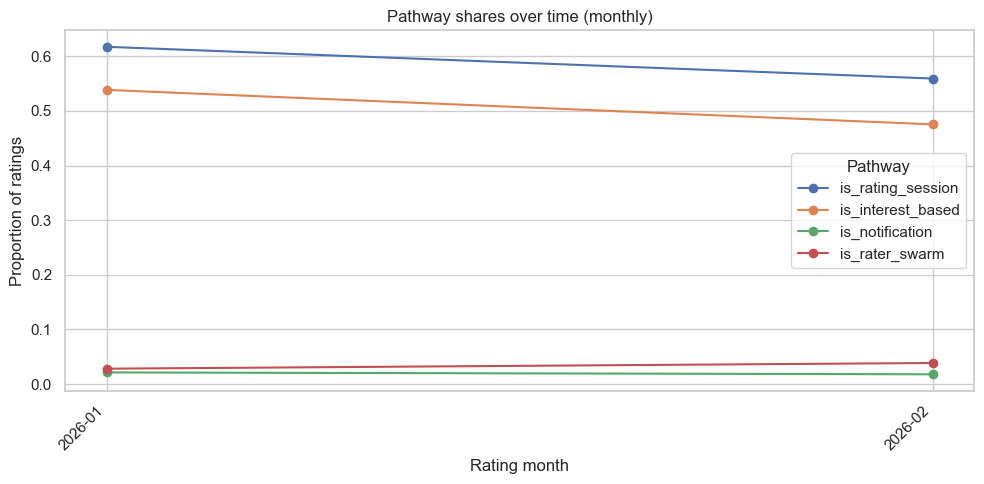

In [16]:
# Line plot of monthly pathway proportions
plt.figure(figsize=(10, 5))
for col in pathway_cols:
    plt.plot(
        monthly_pathways["rating_month"],
        monthly_pathways[col],
        marker="o",
        label=col,
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of ratings")
plt.xlabel("Rating month")
plt.title("Pathway shares over time (monthly)")
plt.legend(title="Pathway")
plt.tight_layout()
plt.show()

### 2b. Pathway mix by rating outcome (helpfulness level)
We also wanted to see whether **different pathways are associated with different rating outcomes**. The dataset contains a `helpfulnessLevel` column, which I used as a proxy for rating outcome.

Here I grouped ratings by `helpfulnessLevel` and computed the mean of each pathway flag within each group. This tells me, for example, whether ratings that end up as "Helpful" are more likely to come from rating sessions or from notifications compared to ratings that are "Not Helpful".

In [17]:
# Pathway proportions by helpfulness level
helpfulness_pathways = (
    df.groupby("helpfulnessLevel")[pathway_cols]
      .mean()
      .reset_index()
)

helpfulness_pathways

,helpfulnessLevel,is_rating_session,is_interest_based,is_notification,is_rater_swarm
0,HELPFUL,0.547418,0.453413,0.025647,0.028560
1,NOT_HELPFUL,0.663821,0.605331,0.008022,0.040848
2,SOMEWHAT_HELPFUL,0.609223,0.515966,0.051619,0.034809


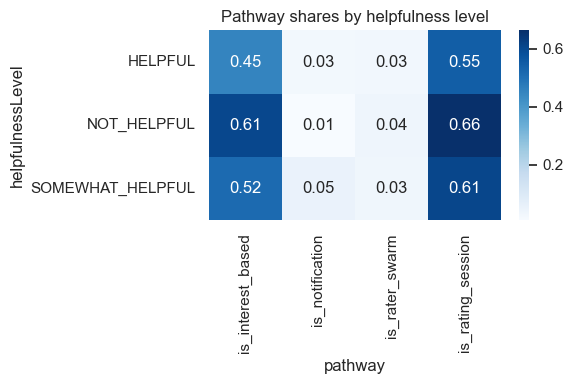

In [18]:
# Heatmap of pathway shares by helpfulness level
helpfulness_melt = helpfulness_pathways.melt(
    id_vars="helpfulnessLevel",
    value_vars=pathway_cols,
    var_name="pathway",
    value_name="proportion",
)

pivot = helpfulness_melt.pivot(
    index="helpfulnessLevel", columns="pathway", values="proportion"
)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues")
ax.set_title("Pathway shares by helpfulness level")
plt.tight_layout()
plt.show()

### 3a. Per-user pathway mix and primary pathway type
I switched from looking at individual ratings to looking at **users**. For each `raterParticipantId`, I computed the fraction of their ratings that fall into each pathway (e.g., what share of this user's ratings are part of sessions, how many are notification-driven, etc.).

Using these per-user shares, I defined a "primary" pathway for each user as the pathway with the highest share of their ratings. This is a simple way to categorize whether users are mainly session raters, interest-based raters, notification-driven raters, or swarm raters, even though they can still use multiple pathways overall.

In [19]:
user_group = df.groupby("raterParticipantId")

user_counts = user_group.size().rename("total_ratings")
user_pathway_means = user_group[[
    "is_rating_session",
    "is_interest_based",
    "is_notification",
    "is_rater_swarm",
]].mean()

user_mix = pd.concat([user_counts, user_pathway_means], axis=1).reset_index()

pathway_cols = [
    "is_rating_session",
    "is_interest_based",
    "is_notification",
    "is_rater_swarm",
]

user_mix["primary_pathway"] = user_mix[pathway_cols].idxmax(axis=1)

user_mix.head()

,raterParticipantId,total_ratings,is_rating_session,is_interest_based,is_notification,is_rater_swarm,primary_pathway
0,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,3,0.000000,0.000000,0.0,0.00,is_rating_session
1,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,50,0.360000,0.260000,0.0,0.08,is_rating_session
2,000045A5FA0CF004F68CBF2913506C37D540CF48522D33...,1,0.000000,0.000000,0.0,0.00,is_rating_session
3,00007F6B0991C1CA1DF283A7615A79999117CAC8C962A5...,2,1.000000,1.000000,0.0,0.00,is_rating_session
4,0000AE9A69E1B5D132C053E253DC42A007EDE2F11C39CF...,3,0.666667,0.666667,0.0,0.00,is_rating_session


### 3b. How many users primarily use one pathway vs. multiple?
We now want to know whether most users behave in a single dominant way (e.g., almost all of their ratings are part of sessions) or if they mix pathways more evenly.

I counted, for each user, how many pathway shares are above 50%. If exactly one pathway exceeds 50%, I consider them a "single-pathway-dominant" user. If multiple pathways exceed 50% or none do, I treat them as more mixed. I then summarized how many users fall into each category and how many ratings they contribute overall.

In [20]:
# Count how many pathways each user uses heavily (> 50% of their ratings)
share_threshold = 0.5

user_mix["num_dominant_pathways"] = (
    (user_mix[pathway_cols] > share_threshold).sum(axis=1)
)

user_mix["pathway_profile"] = np.where(
    user_mix["num_dominant_pathways"] == 1,
    "single_dominant_pathway",
    "mixed_or_weak_preferences",
)

profile_summary = (
    user_mix.groupby("pathway_profile")["raterParticipantId"]
    .nunique()
    .rename("num_users")
    .reset_index()
)

# Also report how many ratings these users contribute
ratings_by_profile = (
    user_mix.groupby("pathway_profile")["total_ratings"].sum().reset_index()
)

profile_summary, ratings_by_profile

(             pathway_profile  num_users
 0  mixed_or_weak_preferences     441938
 1    single_dominant_pathway      42121,
              pathway_profile  total_ratings
 0  mixed_or_weak_preferences        5651059
 1    single_dominant_pathway         848576)

In [21]:
# Distribution of primary pathway types across users
primary_counts = (
    user_mix["primary_pathway"].value_counts(normalize=False)
    .rename_axis("primary_pathway")
    .reset_index(name="num_users")
)

primary_counts["user_share"] = primary_counts["num_users"] / primary_counts["num_users"].sum()

primary_counts

,primary_pathway,num_users,user_share
0,is_rating_session,432577,0.893645
1,is_rater_swarm,20211,0.041753
2,is_notification,19710,0.040718
3,is_interest_based,11561,0.023883


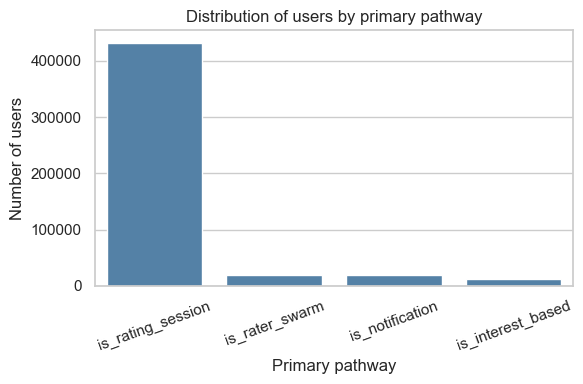

In [22]:
# Bar plot: how many users have each primary pathway
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=primary_counts,
    x="primary_pathway",
    y="num_users",
    color="steelblue",
)
ax.set_ylabel("Number of users")
ax.set_xlabel("Primary pathway")
ax.set_title("Distribution of users by primary pathway")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 3c. Relationship between pathway mix, total ratings, and outcomes
I looked at whether a user's pathway mix is related to how active they are and to the outcomes of their ratings.

I compared the distribution of `total_ratings` across primary pathway types to see whether, for example, session-heavy users tend to rate more overall. For outcomes, I computed, for each user, the fraction of their ratings that are marked as "Helpful" (based on the `helpfulnessLevel` column), and then averaged that by primary pathway. This gives a rough sense of whether certain pathways are associated with higher agreement with helpful notes.

In [23]:
user_helpfulness = (
    df.assign(is_helpful_rating=(df["helpfulnessLevel"] == "HELPFUL"))
      .groupby("raterParticipantId")["is_helpful_rating"]
      .mean()
      .rename("helpful_rate")
)

user_mix = user_mix.merge(
    user_helpfulness,
    on="raterParticipantId",
    how="left",
)

pathway_outcomes = (
    user_mix.groupby("primary_pathway")[["helpful_rate", "total_ratings"]]
    .mean()
    .reset_index()
)

pathway_outcomes

,primary_pathway,helpful_rate,total_ratings
0,is_interest_based,0.665911,25.101721
1,is_notification,0.747362,4.194723
2,is_rater_swarm,0.623533,3.966899
3,is_rating_session,0.664312,13.978046


### 4. Session-based views using first rating on a tweet
For each user and tweet, I kept only the first rating time.
Then I looked at the time between these first-on-tweet ratings for each user.

This gives a sense of how "bursty" users are when they start rating new tweets, and it lets me pick a simple time cutoff for what should count as a session.

In [32]:
# First-on-tweet times per user
first_on_tweet = (
    df.sort_values(["raterParticipantId", "ratedOnTweetId", "ratingCreatedAt"])
      .groupby(["raterParticipantId", "ratedOnTweetId"], as_index=False)
      .first()[["raterParticipantId", "ratedOnTweetId", "ratingCreatedAt"]]
      .rename(columns={"ratingCreatedAt": "first_rating_time"})
)

first_on_tweet = first_on_tweet.sort_values(
    ["raterParticipantId", "first_rating_time"]
).reset_index(drop=True)

first_on_tweet["delta_seconds"] = (
    first_on_tweet.groupby("raterParticipantId")["first_rating_time"]
    .diff()
    .dt.total_seconds()
)

# Drop the very first rating per user (no previous tweet)
first_on_tweet = first_on_tweet.dropna(subset=["delta_seconds"]).reset_index(drop=True)

first_on_tweet["log_delta_seconds"] = np.log1p(first_on_tweet["delta_seconds"])


session_cutoff_sec = 300
first_on_tweet["in_session_first_tweet"] = first_on_tweet["delta_seconds"] <= session_cutoff_sec

first_on_tweet.head()

,raterParticipantId,ratedOnTweetId,first_rating_time,delta_seconds,log_delta_seconds,in_session_first_tweet
0,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2017578816177111423,2026-01-31 17:21:23.365,246841.044,12.416504,False
1,00002C7FD6E0080A69D0AB879C3D9BB704BEFCC078AD40...,2018387895459983768,2026-02-02 22:44:01.605,192158.240,12.166080,False
2,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,2012504826689520078,2026-01-18 19:28:17.202,13609.367,9.518587,False
3,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,2013237382867222793,2026-01-19 19:37:49.288,86972.086,11.373354,False
4,00003D7D222733AE9D37A25B9302040575F6157FECDDB6...,2013237385681629257,2026-01-19 19:38:41.346,52.058,3.971386,True


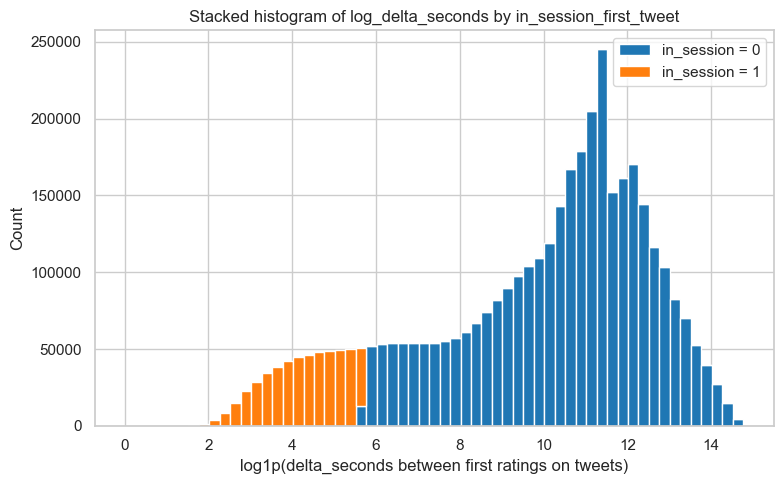

In [33]:

plt.figure(figsize=(8, 5))

bins = np.linspace(
    first_on_tweet["log_delta_seconds"].min(),
    first_on_tweet["log_delta_seconds"].max(),
    60,
)

plt.hist(
    [
        first_on_tweet.loc[~first_on_tweet["in_session_first_tweet"], "log_delta_seconds"],
        first_on_tweet.loc[first_on_tweet["in_session_first_tweet"], "log_delta_seconds"],
    ],
    bins=bins,
    stacked=True,
    label=["in_session = 0", "in_session = 1"],
    color=["tab:blue", "tab:orange"],
)

plt.xlabel("log1p(delta_seconds between first ratings on tweets)")
plt.ylabel("Count")
plt.title("Stacked histogram of log_delta_seconds by in_session_first_tweet")
plt.legend()
plt.tight_layout()
plt.show()

### 4.1 Weekly engagement buckets from rating counts
Now I use each user’s number of ratings per week to put them into simple engagement buckets in that week.
I keep the thresholds pretty rough and then look at how many (user, week) pairs fall into each level.

In [34]:


df["rating_week"] = df["ratingCreatedAt"].dt.to_period("W").apply(lambda r: r.start_time)

weekly_counts = (
    df.groupby(["raterParticipantId", "rating_week"])
      .size()
      .rename("weekly_ratings")
      .reset_index()
)

conditions = [
    weekly_counts["weekly_ratings"] < 5,
    weekly_counts["weekly_ratings"].between(5, 14),
    weekly_counts["weekly_ratings"].between(15, 39),
    weekly_counts["weekly_ratings"] >= 40,
]
choices = [
    "not_engaged",
    "barely_engaged",
    "somewhat_engaged",
    "very_engaged",
]


weekly_counts["engagement_level"] = np.select(
    conditions,
    choices,
    default="not_engaged",
)

weekly_counts["engagement_level"].value_counts().reset_index(name="num_user_weeks")

,engagement_level,num_user_weeks
0,not_engaged,852177
1,barely_engaged,229915
2,somewhat_engaged,71498
3,very_engaged,20635


### 4.2 Regular vs irregular contributors from weeks with sessions
I use my original `is_rating_session` flag to see how many weeks each user shows up with at least one session.
That lets me split users into irregular / somewhat-regular / regular contributors.

In [27]:
session_weeks = (
    df[df["is_rating_session"]]
      .groupby("raterParticipantId")["rating_week"]
      .nunique()
      .rename("num_weeks_with_sessions")
      .reset_index()
)

conditions = [
    session_weeks["num_weeks_with_sessions"] <= 2,
    session_weeks["num_weeks_with_sessions"].between(3, 8),
    session_weeks["num_weeks_with_sessions"] >= 9,
]
choices = ["irregular", "somewhat_regular", "regular"]

session_weeks["regularity"] = np.select(
    conditions,
    choices,
    default="irregular",
)

session_weeks["regularity"].value_counts().reset_index(name="num_users")

,regularity,num_users
0,irregular,172747
1,somewhat_regular,70980


 5. Note-level time-between-ratings and "short-burst" users
The last part flips the view to notes instead of users.
- I look at the time between consecutive ratings on the same note.
- I then flag gaps shorter than 7 seconds and use those to find "short-burst" raters.
- Finally I compare the note-level timing for short-burst users vs everyone else.

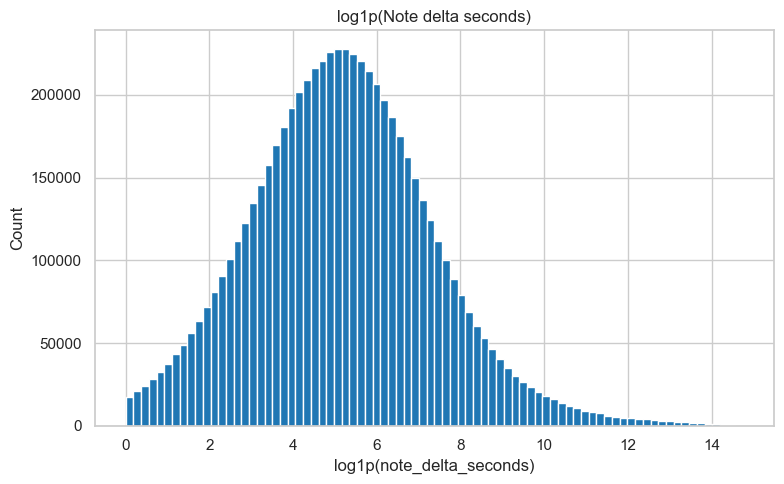

In [28]:

note_sorted = df.sort_values(["noteId", "ratingCreatedAt"]).reset_index(drop=True)

note_sorted["note_delta_seconds"] = (
    note_sorted.groupby("noteId")["ratingCreatedAt"].diff().dt.total_seconds()
)

note_deltas = note_sorted["note_delta_seconds"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(note_deltas), bins=80, color="tab:blue")
plt.xlabel("log1p(note_delta_seconds)")
plt.ylabel("Count")
plt.title("log1p(Note delta seconds)")
plt.tight_layout()
plt.show()

In [29]:

short_burst_threshold = 7.0

note_sorted["is_short_burst_gap"] = note_sorted["note_delta_seconds"] < short_burst_threshold

short_burst_users = note_sorted.loc[
    note_sorted["is_short_burst_gap"], "raterParticipantId"
].unique()

len(short_burst_users)

157873

In [30]:

note_sorted["short_burst_user"] = note_sorted["raterParticipantId"].isin(short_burst_users)

note_sorted["short_burst_user"].value_counts(normalize=True).reset_index(
    name="share_of_ratings"
)

,short_burst_user,share_of_ratings
0,True,0.778129
1,False,0.221871


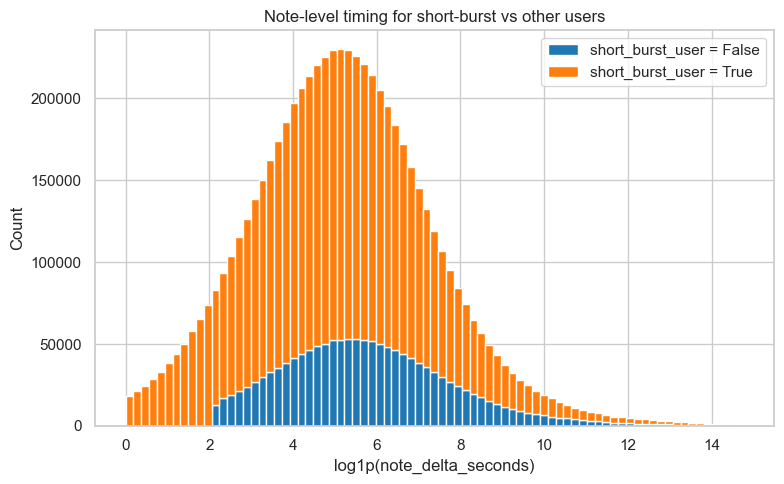

In [31]:
note_nonnull = note_sorted.dropna(subset=["note_delta_seconds"]).copy()
note_nonnull["log_note_delta_seconds"] = np.log1p(note_nonnull["note_delta_seconds"])

plt.figure(figsize=(8, 5))

bins = np.linspace(
    note_nonnull["log_note_delta_seconds"].min(),
    note_nonnull["log_note_delta_seconds"].max(),
    80,
)

plt.hist(
    [
        note_nonnull.loc[~note_nonnull["short_burst_user"], "log_note_delta_seconds"],
        note_nonnull.loc[note_nonnull["short_burst_user"], "log_note_delta_seconds"],
    ],
    bins=bins,
    stacked=True,
    label=["short_burst_user = False", "short_burst_user = True"],
    color=["tab:blue", "tab:orange"],
)

plt.xlabel("log1p(note_delta_seconds)")
plt.ylabel("Count")
plt.title("Note-level timing for short-burst vs other users")
plt.legend()
plt.tight_layout()
plt.show()

## 6. User trajectories: rating vs writing vs requesting

In [ ]:
notes_traj = pd.read_parquet("../Archive-2/sample_user_note_traj.parquet")
ratings_traj = pd.read_parquet("../Archive-2/sample_user_rating_traj.parquet")
requests_traj = pd.read_parquet("../Archive-2/sample_user_request_traj.parquet")

notes_traj.head(), ratings_traj.head(), requests_traj.head()

(                             noteAuthorParticipantId  userMonth  sportsCount  \
 0  0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...         16            0   
 1  0034BCAF4094E1BDB8B458EA45CD0896FD9B5E68BB8426...         18            0   
 2  004BAF746629CC246C75D468FC9B32ADCE2F632DE32B33...         17            0   
 3  004BAF746629CC246C75D468FC9B32ADCE2F632DE32B33...         18            0   
 4  004BAF746629CC246C75D468FC9B32ADCE2F632DE32B33...         27            0   
 
    diaries_&_daily_lifeCount  business_&_entrepreneursCount  \
 0                          0                              0   
 1                          0                              0   
 2                          0                              0   
 3                          0                              0   
 4                          0                              0   
 
    science_&_technologyCount  news_&_social_concernCount  otherCount  \
 0                          0                        

### 6.1 Combine the three datasets into one user-month table
Each dataset uses a different user id column name (`noteAuthorParticipantId`, `raterParticipantId`, `requesterParticipantId`).

Here I rename them all to a shared `userId`, keep only the main count columns, and outer-join them on `(userId, userMonth, calendarMonth)`. Missing values become 0, which means "this user didn't do that action in that month".

In [13]:
notes_small = notes_traj.rename(columns={"noteAuthorParticipantId": "userId"})[
    ["userId", "userMonth", "calendarMonth", "notesCreated"]
]
ratings_small = ratings_traj.rename(columns={"raterParticipantId": "userId"})[
    ["userId", "userMonth", "calendarMonth", "notesRated"]
]
requests_small = requests_traj.rename(columns={"requesterParticipantId": "userId"})[
    ["userId", "userMonth", "calendarMonth", "requestsMade"]
]

user_month = (
    notes_small.merge(ratings_small, on=["userId", "userMonth", "calendarMonth"], how="outer")
              .merge(requests_small, on=["userId", "userMonth", "calendarMonth"], how="outer")
)

for c in ["notesCreated", "notesRated", "requestsMade"]:
    user_month[c] = user_month[c].fillna(0).astype(int)

user_month["calendarMonth"] = user_month["calendarMonth"].astype(str)

user_month

,userId,userMonth,calendarMonth,notesCreated,notesRated,requestsMade
0,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,0,2025-12,0,0,1
1,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,0,2025-11,0,0,1
2,0014F9BA334FB10689F9D089BF47912797FBE78F01E3E3...,0,2025-08,0,0,1
3,00167DE211B4D41B0E054EFD79A9771F2A2097A8285235...,0,2025-11,0,0,1
4,00167DE211B4D41B0E054EFD79A9771F2A2097A8285235...,1,2025-12,0,0,1
...,...,...,...,...,...,...
92276,FFF473DD905D41503CF2EF95C6B3AFF62C142AE2564546...,19,2025-07,0,1,0
92277,FFF473DD905D41503CF2EF95C6B3AFF62C142AE2564546...,20,2025-08,0,1,0
92278,FFF473DD905D41503CF2EF95C6B3AFF62C142AE2564546...,25,2026-01,0,2,0
92279,FFFEA897FAE26B6664E59ED1C9963A8EBDDEE1601CA512...,0,2025-11,0,0,2


### 6.2 Define contribution types and each user-month’s dominant type
I treat a user-month as having:
- **writing** if `notesCreated > 0`
- **rating** if `notesRated > 0`
- **requesting** if `requestsMade > 0`

For "dominant" type, I compare the three counts and take the max. If there is a tie for max (or everything is 0), I label it as `mixed_or_none` so I don't force a fake winner.

In [14]:
user_month["did_write"] = user_month["notesCreated"] > 0
user_month["did_rate"] = user_month["notesRated"] > 0
user_month["did_request"] = user_month["requestsMade"] > 0

count_cols = {
    "writing": "notesCreated",
    "rating": "notesRated",
    "requesting": "requestsMade",
}

user_month["max_count"] = user_month[list(count_cols.values())].max(axis=1)

user_month["dominant_type"] = user_month[list(count_cols.values())].idxmax(axis=1)
user_month["dominant_type"] = user_month["dominant_type"].map({
    "notesCreated": "writing",
    "notesRated": "rating",
    "requestsMade": "requesting",
})

# tie detection
user_month["num_tied_for_max"] = (
    (user_month[list(count_cols.values())].eq(user_month["max_count"], axis=0)).sum(axis=1)
)

user_month.loc[
    (user_month["max_count"] == 0) | (user_month["num_tied_for_max"] > 1),
    "dominant_type",
] = "mixed_or_none"

user_month[["userId", "calendarMonth", "userMonth", "notesCreated", "notesRated", "requestsMade", "dominant_type"]]

,userId,calendarMonth,userMonth,notesCreated,notesRated,requestsMade,dominant_type
0,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,2025-12,0,0,0,1,requesting
1,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,2025-11,0,0,0,1,requesting
2,0014F9BA334FB10689F9D089BF47912797FBE78F01E3E3...,2025-08,0,0,0,1,requesting
3,00167DE211B4D41B0E054EFD79A9771F2A2097A8285235...,2025-11,0,0,0,1,requesting
4,00167DE211B4D41B0E054EFD79A9771F2A2097A8285235...,2025-12,1,0,0,1,requesting
...,...,...,...,...,...,...,...
92276,FFF473DD905D41503CF2EF95C6B3AFF62C142AE2564546...,2025-07,19,0,1,0,rating
92277,FFF473DD905D41503CF2EF95C6B3AFF62C142AE2564546...,2025-08,20,0,1,0,rating
92278,FFF473DD905D41503CF2EF95C6B3AFF62C142AE2564546...,2026-01,25,0,2,0,rating
92279,FFFEA897FAE26B6664E59ED1C9963A8EBDDEE1601CA512...,2025-11,0,0,0,2,requesting


### 6.3 What contribution types are most common in users’ first active month?
Because `userMonth` is defined as "months since the user's first action", the first active month should be `userMonth == 0`.

I look at the dominant type in `userMonth == 0` and report what share of users start out mainly writing vs rating vs requesting (plus mixed/none).

In [7]:
first_month = user_month[user_month["userMonth"] == 0].copy()

first_month_summary = (
    first_month.groupby("dominant_type")["userId"].nunique()
    .rename("num_users")
    .reset_index()
)
first_month_summary["share"] = first_month_summary["num_users"] / first_month_summary["num_users"].sum()
first_month_summary.sort_values("share", ascending=False)

,dominant_type,num_users,share
2,requesting,14201,0.71005
1,rating,5768,0.28840
0,mixed_or_none,23,0.00115
3,writing,8,0.00040


### 6.4 Dominant contribution type by user-month (stacked % plot)
For each `userMonth`, I calculate each user’s dominant contribution type and then compute the percent of users in that userMonth dominated by each type.

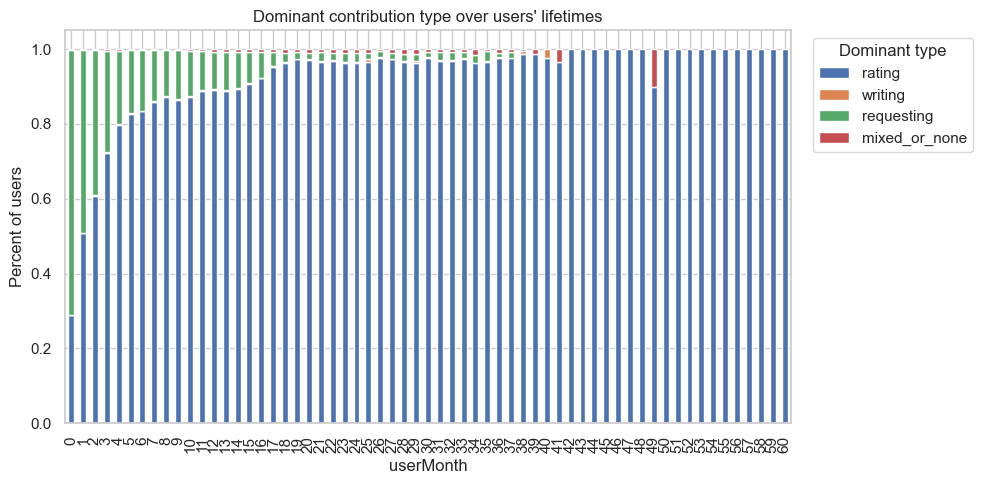

In [8]:
dominant_by_usermonth = (
    user_month.groupby(["userMonth", "dominant_type"])["userId"].nunique()
    .rename("num_users")
    .reset_index()
)

month_totals = dominant_by_usermonth.groupby("userMonth")["num_users"].transform("sum")
dominant_by_usermonth["pct_users"] = dominant_by_usermonth["num_users"] / month_totals

pivot = dominant_by_usermonth.pivot(index="userMonth", columns="dominant_type", values="pct_users").fillna(0)

col_order = ["rating", "writing", "requesting", "mixed_or_none"]
for c in col_order:
    if c not in pivot.columns:
        pivot[c] = 0
pivot = pivot[col_order]

ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_xlabel("userMonth")
ax.set_ylabel("Percent of users")
ax.set_title("Dominant contribution type over users' lifetimes")
ax.legend(title="Dominant type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6.5 Plot a few individual user trajectories
To make this more concrete, I picked a small sample of users and plotted their monthly counts of:
- notes written (`notesCreated`)
- notes rated (`notesRated`)
- requests made (`requestsMade`)

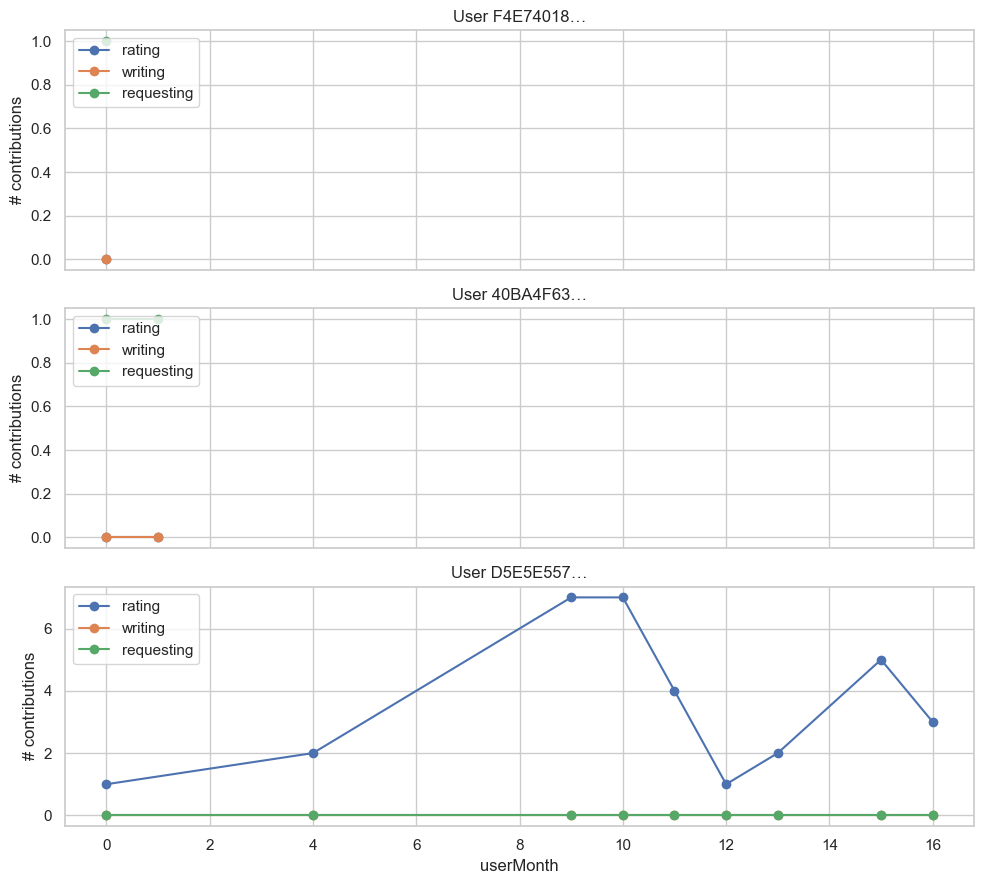

In [9]:
# Sample a few users and plot their trajectories
np.random.seed(0)
sample_users = np.random.choice(user_month["userId"].unique(), size=3, replace=False)

fig, axes = plt.subplots(len(sample_users), 1, figsize=(10, 3 * len(sample_users)), sharex=True)
if len(sample_users) == 1:
    axes = [axes]

for ax, uid in zip(axes, sample_users):
    u = user_month[user_month["userId"] == uid].sort_values("userMonth")
    ax.plot(u["userMonth"], u["notesRated"], marker="o", label="rating")
    ax.plot(u["userMonth"], u["notesCreated"], marker="o", label="writing")
    ax.plot(u["userMonth"], u["requestsMade"], marker="o", label="requesting")
    ax.set_title(f"User {str(uid)[:8]}…")
    ax.set_ylabel("# contributions")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("userMonth")
plt.tight_layout()
plt.show()

### 6.6 Average user "age" by calendar month and contribution type
For each calendar month (e.g. 2025-06), I compute the average `userMonth` among users who did each type of activity.

I plot this over time for rating vs writing vs requesting.

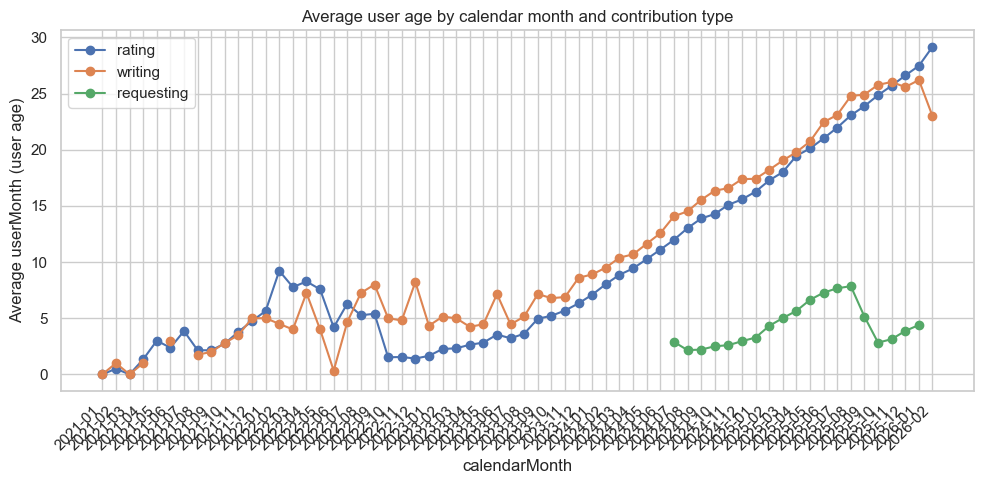

,calendarMonth,rating,writing,requesting
0,2021-01,0.000000,0.0,NaN
1,2021-02,0.500000,1.0,NaN
2,2021-03,0.000000,0.0,NaN
3,2021-04,1.333333,1.0,NaN
4,2021-05,3.000000,NaN,NaN


In [10]:
cal = user_month.copy()

avg_age = []
for typ, col in [("rating", "notesRated"), ("writing", "notesCreated"), ("requesting", "requestsMade")]:
    tmp = cal[cal[col] > 0].groupby("calendarMonth")["userMonth"].mean().rename(typ)
    avg_age.append(tmp)

avg_age_df = pd.concat(avg_age, axis=1).reset_index()
avg_age_df = avg_age_df.sort_values("calendarMonth")

plt.figure(figsize=(10, 5))
for typ in ["rating", "writing", "requesting"]:
    if typ in avg_age_df.columns:
        plt.plot(avg_age_df["calendarMonth"], avg_age_df[typ], marker="o", label=typ)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Average userMonth (user age)")
plt.xlabel("calendarMonth")
plt.title("Average user age by calendar month and contribution type")
plt.legend()
plt.tight_layout()
plt.show()

avg_age_df.head()

### 6.7 Regular / somewhat regular / irregular contributors (calendar-month version)
Last week we bucketed users based on how many weeks they contributed in.
Here I do the same idea but using calendar months:
- For each user, count how many distinct calendar months they have any contributions.
- Label them as irregular / somewhat_regular / regular.

Then, for each calendar month, I sum up how many ratings / notes / requests came from each regularity bucket.

In [ ]:
# Regularity based on number of active calendar months
cal["any_contrib"] = (cal["notesRated"] + cal["notesCreated"] + cal["requestsMade"]) > 0

months_active = (
    cal[cal["any_contrib"]]
    .groupby("userId")["calendarMonth"].nunique()
    .rename("num_active_months")
    .reset_index()
)

conditions = [
    months_active["num_active_months"] <= 2,
    months_active["num_active_months"].between(3, 8),
    months_active["num_active_months"] >= 9,
]
choices = ["irregular", "somewhat_regular", "regular"]
months_active["regularity"] = np.select(conditions, choices, default="irregular")

cal = cal.merge(months_active[["userId", "regularity"]], on="userId", how="left")

# Sum contributions by calendarMonth + regularity
monthly_by_reg = (
    cal.groupby(["calendarMonth", "regularity"])[["notesRated", "notesCreated", "requestsMade"]]
    .sum()
    .reset_index()
)

monthly_by_reg.head()

,calendarMonth,regularity,notesRated,notesCreated,requestsMade
0,2021-01,regular,2,2,0
1,2021-02,regular,2,1,0
2,2021-02,somewhat_regular,4,0,0
3,2021-03,regular,35,4,0
4,2021-04,regular,26,1,0


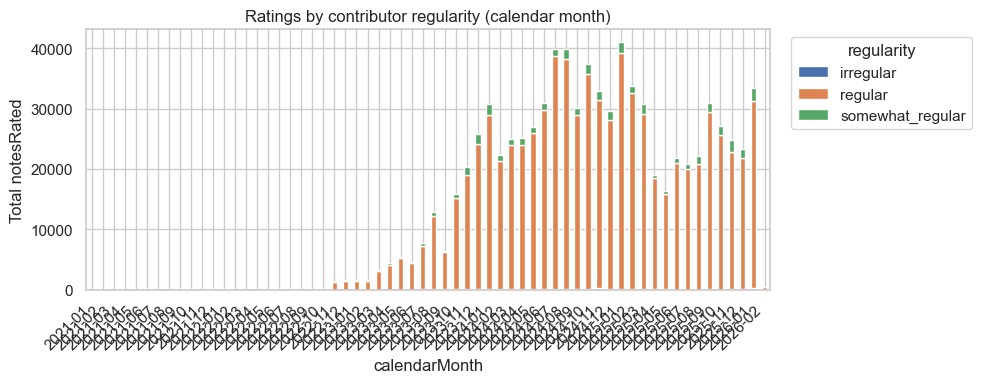

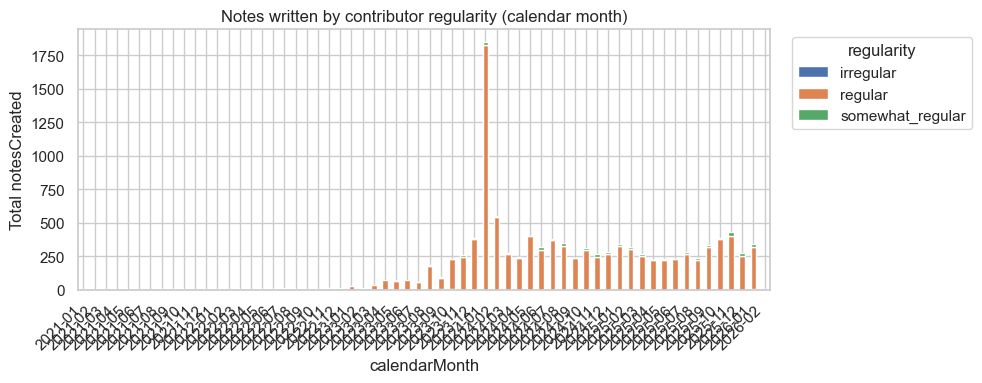

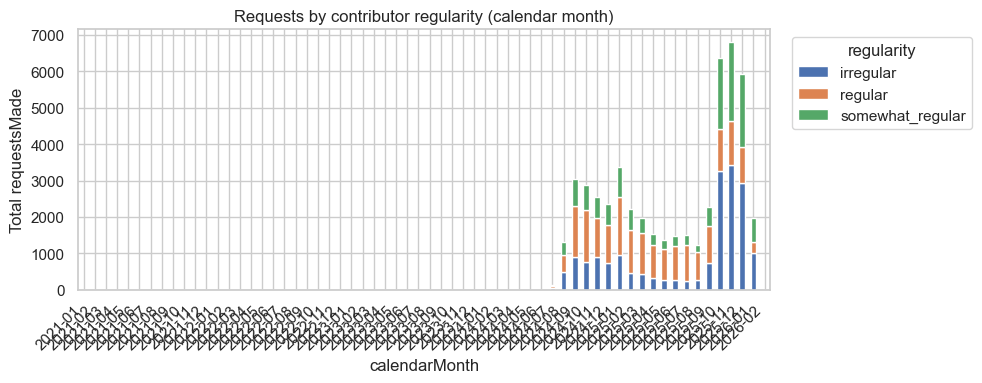

In [ ]:
# Plot
for metric, title in [
    ("notesRated", "Ratings"),
    ("notesCreated", "Notes written"),
    ("requestsMade", "Requests"),
]:
    pivot = monthly_by_reg.pivot(index="calendarMonth", columns="regularity", values=metric).fillna(0)
    pivot = pivot.sort_index()

    ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 4))
    ax.set_title(f"{title} by contributor regularity (calendar month)")
    ax.set_xlabel("calendarMonth")
    ax.set_ylabel(f"Total {metric}")
    ax.legend(title="regularity", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### 6.8 Answer the questions (with the notebook’s own numbers)
These cells compute and print the exact numbers used to answer:
- most common contribution type in users’ first active month
- average user age (`userMonth`) by calendar month and contribution type
- monthly totals by contributor regularity bucket

This is here so my written answers match what the notebook outputs.

In [ ]:
# Q1) Most common contribution type in users’ first active month (userMonth == 0)
first_month = user_month[user_month["userMonth"] == 0].copy()

first_month_counts = (
    first_month.groupby("dominant_type")["userId"].nunique()
    .sort_values(ascending=False)
)
first_month_share = (first_month_counts / first_month_counts.sum()).rename("share")

pd.concat(
    [first_month_counts.rename("num_users"), first_month_share],
    axis=1,
).reset_index().rename(columns={"index": "dominant_type"})

In [ ]:
# Q2) Average user age (userMonth) by calendar month and contribution type
# (this uses the same logic as the plot above, but prints a table + a specific example month)

avg_age = []
for typ, col in [("rating", "notesRated"), ("writing", "notesCreated"), ("requesting", "requestsMade")]:
    tmp = user_month[user_month[col] > 0].groupby("calendarMonth")["userMonth"].mean().rename(typ)
    avg_age.append(tmp)

avg_age_df = pd.concat(avg_age, axis=1).sort_index()

example_month = "2025-06"
example_row = avg_age_df.loc[[example_month]] if example_month in avg_age_df.index else None

avg_age_df.tail(12), example_row

In [ ]:
# Q3) Monthly totals of ratings/notes/requests from irregular vs somewhat vs regular contributors
# Regularity here is based on number of active calendar months (same as Section 6.7)

cal = user_month.copy()
cal["any_contrib"] = (cal["notesRated"] + cal["notesCreated"] + cal["requestsMade"]) > 0

months_active = (
    cal[cal["any_contrib"]]
    .groupby("userId")["calendarMonth"].nunique()
    .rename("num_active_months")
    .reset_index()
)

conditions = [
    months_active["num_active_months"] <= 2,
    months_active["num_active_months"].between(3, 8),
    months_active["num_active_months"] >= 9,
]
choices = ["irregular", "somewhat_regular", "regular"]
months_active["regularity"] = np.select(conditions, choices, default="irregular")

cal = cal.merge(months_active[["userId", "regularity"]], on="userId", how="left")

monthly_by_reg = (
    cal.groupby(["calendarMonth", "regularity"])[["notesRated", "notesCreated", "requestsMade"]]
    .sum()
    .reset_index()
)

# Show the last 6 calendar months for each metric
last_months = sorted(cal["calendarMonth"].unique())[-6:]

out = {}
for metric in ["notesRated", "notesCreated", "requestsMade"]:
    wide = (
        monthly_by_reg.pivot(index="calendarMonth", columns="regularity", values=metric)
        .fillna(0)
        .astype(int)
        .sort_index()
    )
    for c in ["irregular", "somewhat_regular", "regular"]:
        if c not in wide.columns:
            wide[c] = 0
    out[metric] = wide.loc[last_months, ["irregular", "somewhat_regular", "regular"]]

out